# Impute nanoC&T data and create per-gene methylation/acetylation layer via regulatory inference graph

This code needs previous scGlue integration output for regulatory inference. 

You can still do imputation, but cannot create inferred gene layers if you haven't run scGlue. 

However, for some parts of the analysis (like creating landscape embedding), gene layers are not necessary.

In [1]:
import sys
import numpy as np
import anndata as ad
from markdown_it.common.html_re import cdata

sys.path.insert(0, '..')

import src as scit
import anndata as ad

In [2]:
adata = ad.read_h5ad('private/data/marek/combined.h5ad')

In [4]:
# Imputation
scit.gr.knn(adata, 'X_multi_spectral', n_neighbors=4) # X_glue is also good
g = scit.gr.neighbor_graph(adata)
scit.gr.knn_impute(adata, g, ['acet', 'meth'], 1)

Info: Imputing layers ['acet', 'meth'] with number of neighbors per cell of 5 and strength of 1.0.


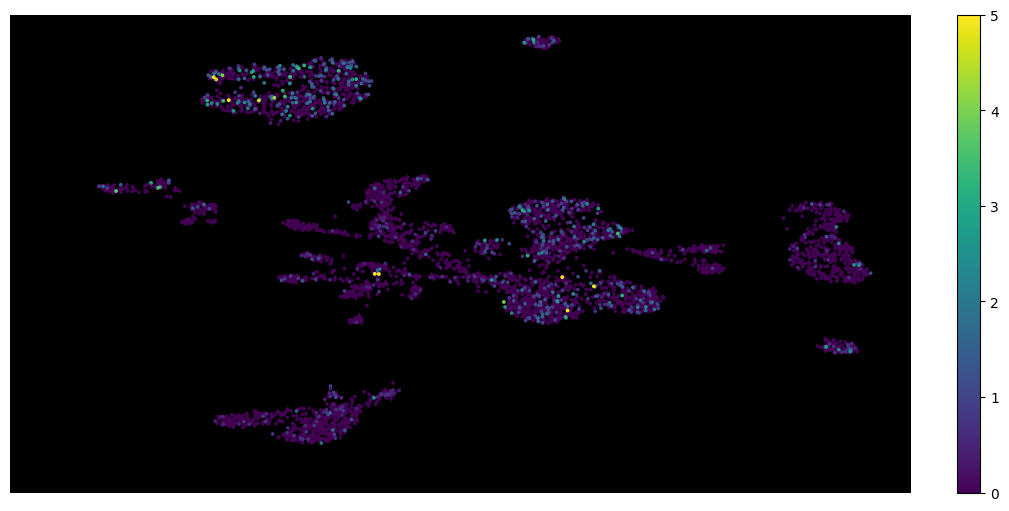

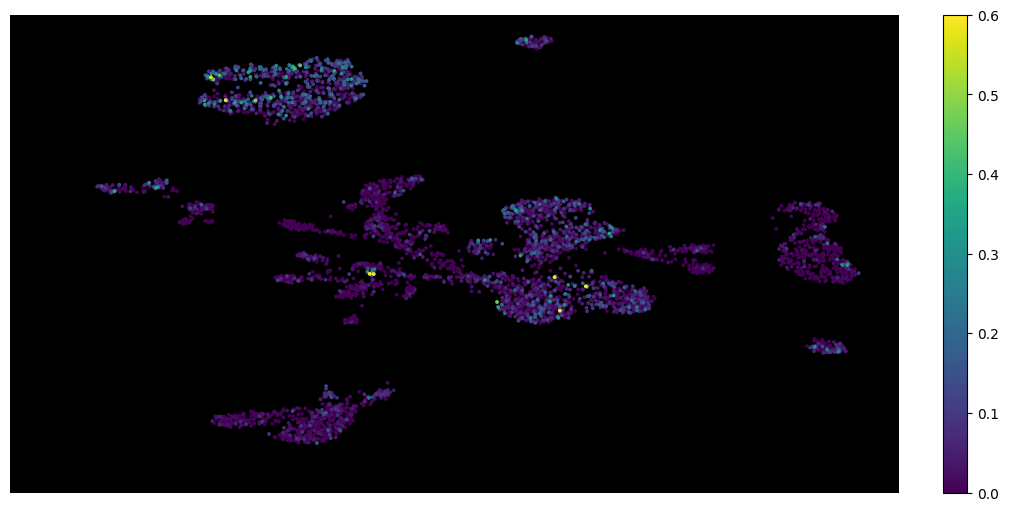

In [16]:
# Check result
pre_imp_acet = scit.tl.make_layer_config('acet', log_transform=False, normalize_with_obs_counts=True, feature_names=adata.var_names)
imputed_acet = scit.tl.make_layer_config('imputed_acet', log_transform=False, normalize_with_obs_counts=False, feature_names=adata.var_names)

# Change var index to find a suitable var as an example
var_index = 'chr2:77170000-77175000'

scit.tl.layer_pick_features(adata, pre_imp_acet, var_index)
scit.tl.copy_to_obs(adata, pre_imp_acet)
scit.pl.embedding2d(adata, 'X_umap', 'copied_data', vminmax=(0,5), black_background=True)

scit.tl.layer_pick_features(adata, imputed_acet, var_index)
scit.tl.copy_to_obs(adata, imputed_acet)
scit.pl.embedding2d(adata, 'X_umap', 'copied_data', vminmax=(0,0.6), black_background=True)

Load gene names and regulatory links from scGLUE

If you don't have the .links file and have not performed scGLUE
integration, you cannot run this code.

However, if you have a regulatory matrix from somewhere else, you can use it. Just skip the next cell and load regulatory matrix/create it manually.

In [15]:
import pickle

# Load gene names and regulatory links from scGLUE

rna = ad.read_h5ad('../data/scglue/user/emb-rna.h5ad')
reg = scit.ld.regulatory_links('../data/scglue/user/bin.links', rna)
# scit.tl.regulatory_ensure_promoter_included(reg, adata, rna)

# Get sparse adjacency matrix of regulation (n gene features x n bin features)

R = scit.tl.get_regulatory_matrix(reg, names, adata.var_names)

Info: 73 features had promoter overlapping with at least one other feature, creating ambiguity


NameError: name 'adata' is not defined

In [20]:
del rna.obsp
del rna.varm
del rna.obsm
del rna.uns

In [22]:
rna.write_h5ad('private/shell_rna.h5ad')

In [19]:
rna = ad.read_h5ad('../data/scglue/user/emb-rna.h5ad')

In [13]:
import polars as pl
names = pl.read_csv('private/rna_features.csv')['column_0'].to_numpy()

In [ ]:
import polars as pl
pl.DataFrame(rna.var_names.to_numpy()).write_csv('private/rna_features.csv')

In [6]:
# Alternatively, create a regulatory matrix by linking gene to bins
# in a sparse binary csr matrix.

# import scipy.sparse as sps
# R = sps.csr_matrix( ..., dtype=np.bool_)

In [7]:
lc_meth = scit.tl.make_layer_config('meth_binary')
lc_acet = scit.tl.make_layer_config('acet_binary')

# Infer gene acetylation/methylation layers
scit.tl.infer_layer(adata, R, lc_acet, names, 'acet')
scit.tl.infer_layer(adata, R, lc_meth, names, 'meth')

lc_meth = scit.tl.make_layer_config('imputed_meth')
lc_acet = scit.tl.make_layer_config('imputed_acet')

# Infer gene acetylation/methylation layers
scit.tl.infer_layer(adata, R, lc_acet, names, 'acet_imp')
scit.tl.infer_layer(adata, R, lc_meth, names, 'meth_imp')

In [11]:
adata.write_h5ad('private/data/glue/cttag_2025_full.h5ad')

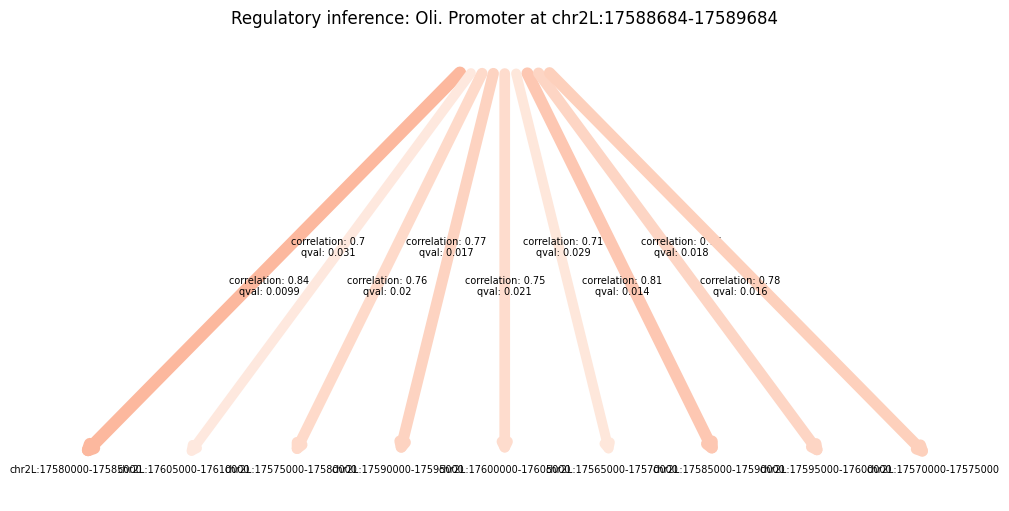

In [10]:
# Visualize Oli regulation

scit.pl.regulatory_links(reg, 'Oli')

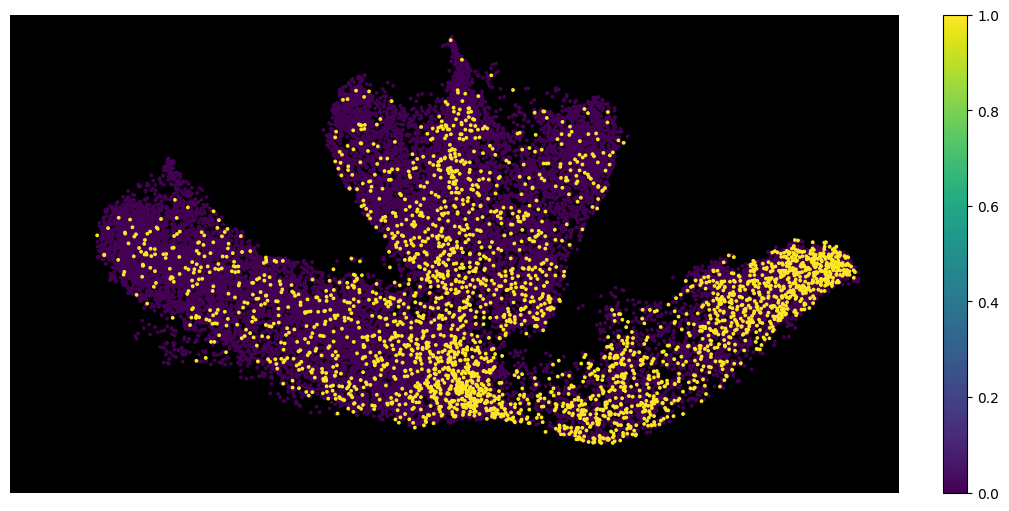

In [12]:
# The inferred data is in .obsm (since feature number is different)
acet = scit.tl.make_layer_config('acet', in_obsm=True, feature_names=names, feature_active_threshold=0)

# Visualize Oli gene acetylation
# The layer to infer Oli regulation is binary,
# however, the inferred layer divides signal by total number of
# involved bins (Oli regulation is spread over 9 bins)
scit.tl.layer_pick_features(adata, acet, 'Oli')
scit.tl.copy_to_obs(adata, acet, binarize=True)
scit.pl.embedding2d(adata, 'X_umap', 'copied_data', black_background=True)

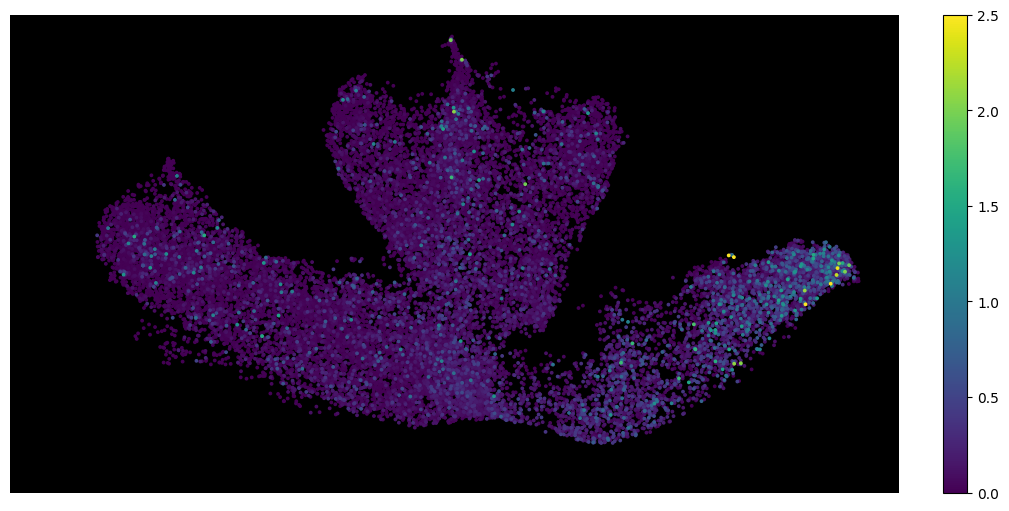

In [15]:
# The inferred data is in .obsm (since feature number is different)
acet = scit.tl.make_layer_config('acet_imp', in_obsm=True, feature_names=names, feature_active_threshold=2)
scit.tl.layer_pick_features(adata, acet, 'Oli')
scit.tl.copy_to_obs(adata, acet)
scit.pl.embedding2d(adata, 'X_umap', 'copied_data', vminmax=(0,2.5),black_background=True)

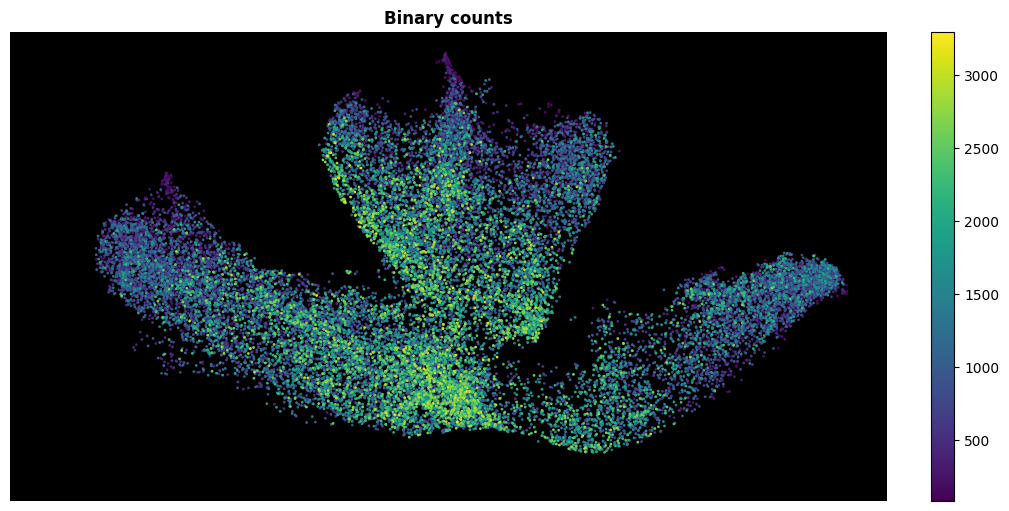

In [16]:
lc_acet_full = scit.tl.make_layer_config(
    'acet', in_obsm=True, feature_active_threshold=0)
X = lc_acet_full.transform(adata, binarize=True)
adata.obs['copied_data'] = X.sum(axis=1).A1
scit.pl.embedding2d(adata, 'X_umap', 'copied_data', size=1, black_background=True, title='Binary counts')